# Defense vs Tech: Correlation and Risk Analysis

This notebook analyzes whether major defense contractors behaved as meaningful diversifiers relative to the technology sector from **2020-01-01 to 2025-12-31**.

Main question:

- did `LMT`, `NOC`, and `GD` provide stable diversification versus `XLK`, or was the relationship regime-dependent?

In [92]:
# Install required packages
%pip install -q numpy pandas matplotlib seaborn statsmodels scikit-learn arch

# Set up local matplotlib config directory
import os
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

Note: you may need to restart the kernel to use updated packages.


In [93]:
# imports
import warnings
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from arch import arch_model
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

# notebook display settings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# config
TICKERS: List[str] = ["LMT", "NOC", "GD", "XLK"]
DEFENSE_TICKERS: List[str] = ["LMT", "NOC", "GD"]
TECH_TICKER = "XLK"
START_DATE = "2020-01-01"
END_DATE = "2025-12-31"
ROLLING_WINDOW = 30
REGIME_WINDOW = 30
TRADING_DAYS_PER_YEAR = 252
RIDGE_ALPHA = 1.0
LASSO_ALPHA = 0.0005
MOMENTUM_WINDOW = 30

# local repo data path
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "data" / "defense_vs_tech_yahoo_2020_2025.csv"
EXPORT_DIR = BASE_DIR / "outputs"
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Tickers: {TICKERS}")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Rolling window: {ROLLING_WINDOW} trading days")
print(f"Local dataset: {DATA_PATH}")


Tickers: ['LMT', 'NOC', 'GD', 'XLK']
Date range: 2020-01-01 to 2025-12-31
Rolling window: 30 trading days
Local dataset: /Users/akshit/Code/IC Quant Project/data/defense_vs_tech_yahoo_2020_2025.csv


## Data Choices

- Returns and risk metrics use `Adj Close`.
- The dataset is pre-downloaded and stored locally in `data/defense_vs_tech_yahoo_2020_2025.csv`.
- Missing values are audited first, then forward-filled conservatively.
- Daily frequency is preserved. Smoothing comes from rolling windows rather than resampling.


In [94]:
# data loading and preprocessing

# loads the pre-downloaded repo dataset
def load_local_data(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f"Local dataset not found: {csv_path}")
    df = pd.read_csv(csv_path, header=[0, 1], index_col=0, parse_dates=True)
    if df.empty:
        raise ValueError("Local dataset is empty.")
    return df.sort_index()


# pulls one field out of the local multiindex
def extract_field(raw_df: pd.DataFrame, field: str) -> pd.DataFrame:
    extracted = raw_df[field].copy() if isinstance(raw_df.columns, pd.MultiIndex) else raw_df[[field]].copy()
    if isinstance(extracted, pd.Series):
        extracted = extracted.to_frame(name=TICKERS[0])
    return extracted.sort_index()


# summarizes missing values
def audit_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "first_valid": df.apply(pd.Series.first_valid_index),
        "last_valid": df.apply(pd.Series.last_valid_index),
    }).sort_values("missing_count", ascending=False)


# forward fills empty missing values
def clean_price_data(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.sort_index().ffill().dropna(how="all")


# converts prices into daily returns
def calculate_returns(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.pct_change().dropna(how="all")


# rebases prices to a common start value
def normalize_prices(prices: pd.DataFrame, base: float = 100.0) -> pd.DataFrame:
    return prices.div(prices.iloc[0]).mul(base)


# loads and cleans adjusted close data
raw_data = load_local_data(DATA_PATH)
adj_close_raw = extract_field(raw_data, "Adj Close")
missing_audit = audit_missing_values(adj_close_raw)
adj_close = clean_price_data(adj_close_raw)
returns = calculate_returns(adj_close)
normalized_prices = normalize_prices(adj_close)

print("Missing-value audit:")
display(missing_audit)
print("Adjusted close sample:")
display(adj_close.head())


Missing-value audit:


,missing_count,missing_pct,first_valid,last_valid
Ticker,,,,
GD,0,0.0000,2020-01-02,2025-12-30
LMT,0,0.0000,2020-01-02,2025-12-30
NOC,0,0.0000,2020-01-02,2025-12-30
XLK,0,0.0000,2020-01-02,2025-12-30


Adjusted close sample:


Ticker,GD,LMT,NOC,XLK
Date,,,,
2020-01-02,153.6619,337.6092,321.1186,44.2942
2020-01-03,155.1690,349.7569,338.5513,43.7962
2020-01-06,156.8139,349.2244,339.2916,43.9005
2020-01-07,155.0313,350.3994,338.5152,43.8815
2020-01-08,155.4274,347.4660,334.2902,44.3511


## Concepts

- **GARCH** means a volatility model that updates risk using recent shocks and recent volatility. In plain language: it tries to estimate when markets are in calmer periods versus more unstable periods.
- **R-squared (`R^2`)** measures how much of a defense stock's return variation is explained by `XLK`.
- **TSS** means *Total Sum of Squares*: the target series' total variation.
- **RSS** means *Residual Sum of Squares*: the variation left unexplained by the model.
- **Ridge regularization** shrinks coefficients toward zero while usually keeping all features.
- **Lasso regularization** can shrink some coefficients all the way to zero, which acts like feature selection.

In [ ]:
# statistics modeling and compact strategy tests

# annualizes compounded return
def annualize_return(daily_returns: pd.Series) -> float:
    compounded = (1 + daily_returns).prod()
    periods = daily_returns.shape[0]
    return compounded ** (TRADING_DAYS_PER_YEAR / periods) - 1 if periods > 0 else np.nan


# annualizes daily volatility
def annualize_volatility(daily_returns: pd.Series) -> float:
    return daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)


# calculates max peak to trough loss
def calculate_max_drawdown(daily_returns: pd.Series) -> float:
    cumulative = (1 + daily_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative.div(running_max) - 1
    return drawdown.min()


# builds summary stats for each ticker
def get_summary_stats(returns_df: pd.DataFrame) -> pd.DataFrame:
    rows = {}
    for ticker in returns_df.columns:
        series = returns_df[ticker].dropna()
        rows[ticker] = {
            "annual_return": annualize_return(series),
            "annual_volatility": annualize_volatility(series),
            "max_drawdown": calculate_max_drawdown(series),
            "average_daily_return": series.mean(),
            "daily_volatility": series.std(),
            "kurtosis": series.kurtosis(),
        }
    return pd.DataFrame(rows).T.sort_values("annual_return", ascending=False)


# calculates rolling annualized volatility
def get_rolling_volatility(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    return returns_df.rolling(window).std() * np.sqrt(TRADING_DAYS_PER_YEAR)


# calculates full period correlation matrix
def get_correlation_matrix(returns_df: pd.DataFrame) -> pd.DataFrame:
    return returns_df.corr()


# calculates rolling correlation vs xlk
def get_rolling_correlation(returns_df: pd.DataFrame, benchmark: str, tickers: List[str], window: int) -> pd.DataFrame:
    data = {}
    for ticker in tickers:
        data[f"{ticker}_vs_{benchmark}"] = returns_df[ticker].rolling(window).corr(returns_df[benchmark])
    return pd.DataFrame(data)


# buckets xlk volatility into simple regimes
def build_regime_table(rolling_vol_df: pd.DataFrame, returns_df: pd.DataFrame, benchmark: str) -> pd.DataFrame:
    regime_signal = rolling_vol_df[benchmark].dropna()
    
    # creates tertile cutoffs
    quantiles = regime_signal.quantile([0.33, 0.67])
    low_cutoff = quantiles.loc[0.33]
    high_cutoff = quantiles.loc[0.67]
    
    # assigns regime labels based on volatility
    regime = pd.Series(index=regime_signal.index, dtype="object")
    regime[regime_signal <= low_cutoff] = "Low Vol"
    regime[(regime_signal > low_cutoff) & (regime_signal <= high_cutoff)] = "Medium Vol"
    regime[regime_signal > high_cutoff] = "High Vol"
    
    # merges and averages the returns per regime
    regime_returns = returns_df.join(regime.rename("regime"), how="inner")
    grouped = regime_returns.groupby("regime")
    return grouped.mean().T.rename(columns={
        "Low Vol": "avg_return_low_vol",
        "Medium Vol": "avg_return_medium_vol",
        "High Vol": "avg_return_high_vol",
    })


# fits defense vs xlk regression
def fit_pair_regression(target: pd.Series, benchmark: pd.Series) -> Dict[str, float]:
    # aligns dates
    aligned = pd.concat([target, benchmark], axis=1).dropna()
    aligned.columns = ["target", "benchmark"]
    
    # fits ordinary least squares
    X = sm.add_constant(aligned["benchmark"])
    y = aligned["target"]
    model = sm.OLS(y, X).fit()
    fitted = model.predict(X)
    
    # calculates variation scores and residuals
    residuals = y - fitted
    rss = float(np.square(residuals).sum())
    tss = float(np.square(y - y.mean()).sum())
    rmse = float(np.sqrt(mean_squared_error(y, fitted)))
    mae = float(mean_absolute_error(y, fitted))
    
    return {
        "alpha": float(model.params["const"]),
        "beta": float(model.params["benchmark"]),
        "correlation": float(aligned.corr().iloc[0, 1]),
        "r_squared": float(model.rsquared),
        "rmse": rmse,
        "mae": mae,
        "rss": rss,
        "tss": tss,
        "rss_to_tss": rss / tss if tss else np.nan,
    }


# builds lagged features for next day prediction
def build_predictive_features(returns_df: pd.DataFrame, target_ticker: str, benchmark_ticker: str) -> pd.DataFrame:
    feature_df = pd.DataFrame(index=returns_df.index)
    feature_df["target_lag_1"] = returns_df[target_ticker].shift(1)
    feature_df["target_lag_5"] = returns_df[target_ticker].rolling(5).mean().shift(1)
    feature_df["benchmark_lag_1"] = returns_df[benchmark_ticker].shift(1)
    feature_df["benchmark_lag_5"] = returns_df[benchmark_ticker].rolling(5).mean().shift(1)
    feature_df["target_next_day"] = returns_df[target_ticker]
    return feature_df.dropna()


# compares ols ridge and lasso
def compare_regularized_models(features_df: pd.DataFrame, ridge_alpha: float, lasso_alpha: float) -> pd.DataFrame:
    X = features_df.drop(columns=["target_next_day"])
    y = features_df["target_next_day"]
    
    # simple 80-20 train test split without shuffling for time series
    split_idx = int(len(features_df) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    models = {
        "OLS": LinearRegression(),
        "Ridge": Ridge(alpha=ridge_alpha),
        "Lasso": Lasso(alpha=lasso_alpha),
    }

    rows = []
    # scores each predictive model against test slice
    for name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        rows.append({
            "model": name,
            "test_r_squared": model.score(X_test, y_test),
            "test_rmse": np.sqrt(mean_squared_error(y_test, predictions)),
            "test_mae": mean_absolute_error(y_test, predictions),
        })
    return pd.DataFrame(rows).set_index("model")


# fits garch conditional volatility for each ticker
def get_garch_volatility(returns_df: pd.DataFrame) -> pd.DataFrame:
    garch_data = {}
    for ticker in returns_df.columns:
        series = returns_df[ticker].dropna() * 100
        model = arch_model(series, vol="Garch", p=1, q=1, mean="Zero", dist="normal")
        fit = model.fit(disp="off")
        garch_data[ticker] = fit.conditional_volatility / 100 * np.sqrt(TRADING_DAYS_PER_YEAR)
    return pd.DataFrame(garch_data)


# original same day regime test
# keeps the false positive example
def backtest_biased_regime_strategy(returns_df: pd.DataFrame, rolling_vol_df: pd.DataFrame, defense_tickers: List[str], benchmark: str) -> tuple[pd.Series, pd.DataFrame]:
    regime_signal = rolling_vol_df[benchmark].dropna()
    low_cutoff = regime_signal.quantile(0.33)
    high_cutoff = regime_signal.quantile(0.67)
    
    # creates trailing signal arrays
    trailing_return = adj_close[defense_tickers + [benchmark]].pct_change(MOMENTUM_WINDOW)
    trailing_vol = rolling_vol_df[defense_tickers]
    
    log_rows = []
    strategy_returns = []
    strategy_index = []

    # processes identically matched dates allowing lookahead
    for date in regime_signal.index.intersection(returns_df.index):
        vol_value = regime_signal.loc[date]
        
        # logic switches based on same day vol cutoff
        if vol_value <= low_cutoff:
            chosen = benchmark
            label = "Low Vol -> Hold XLK"
        elif vol_value <= high_cutoff:
            chosen = trailing_return.loc[date, defense_tickers].idxmax()
            label = f"Medium Vol -> Momentum {chosen}"
        else:
            chosen = trailing_vol.loc[date, defense_tickers].idxmin()
            label = f"High Vol -> Low-Vol {chosen}"
            
        strategy_index.append(date)
        strategy_returns.append(returns_df.loc[date, chosen])
        log_rows.append({
            "signal_date": date,
            "chosen_asset": chosen,
            "signal_state": label,
            "strategy_return": returns_df.loc[date, chosen],
            "benchmark_return": returns_df.loc[date, benchmark],
        })

    return pd.Series(strategy_returns, index=strategy_index, name="biased_regime_strategy"), pd.DataFrame(log_rows)


# corrected one day lagged regime test
def backtest_regime_strategy(returns_df: pd.DataFrame, rolling_vol_df: pd.DataFrame, defense_tickers: List[str], benchmark: str) -> tuple[pd.Series, pd.DataFrame]:
    regime_signal = rolling_vol_df[benchmark].dropna()
    low_cutoff = regime_signal.quantile(0.33)
    high_cutoff = regime_signal.quantile(0.67)
    
    trailing_return = adj_close[defense_tickers + [benchmark]].pct_change(MOMENTUM_WINDOW)
    trailing_vol = rolling_vol_df[defense_tickers]
    
    log_rows = []
    strategy_returns = []
    strategy_index = []

    eligible_dates = regime_signal.index.intersection(returns_df.index)
    
    # loops over signal dates but executes trades tomorrow
    for signal_date in eligible_dates[:-1]:
        trade_loc = returns_df.index.get_loc(signal_date) + 1
        trade_date = returns_df.index[trade_loc]
        vol_value = regime_signal.loc[signal_date]
        
        # rotation rules using today's data to pick tomorrow's exposure
        if vol_value <= low_cutoff:
            chosen = benchmark
            label = "Low Vol -> Hold XLK"
        elif vol_value <= high_cutoff:
            chosen = trailing_return.loc[signal_date, defense_tickers].idxmax()
            label = f"Medium Vol -> Momentum {chosen}"
        else:
            chosen = trailing_vol.loc[signal_date, defense_tickers].idxmin()
            label = f"High Vol -> Low-Vol {chosen}"
            
        strategy_index.append(trade_date)
        strategy_returns.append(returns_df.loc[trade_date, chosen])
        log_rows.append({
            "signal_date": signal_date,
            "trade_date": trade_date,
            "chosen_asset": chosen,
            "signal_state": label,
            "strategy_return": returns_df.loc[trade_date, chosen],
            "benchmark_return": returns_df.loc[trade_date, benchmark],
        })

    return pd.Series(strategy_returns, index=strategy_index, name="regime_strategy"), pd.DataFrame(log_rows)


# rotates into defense only when xlk weakens
def backtest_momentum_strategy(returns_df: pd.DataFrame, rolling_vol_df: pd.DataFrame, defense_tickers: List[str], benchmark: str) -> tuple[pd.Series, pd.DataFrame]:
    # prepares trailing momentum and finds overlap dates
    benchmark_momentum = adj_close[benchmark].pct_change(MOMENTUM_WINDOW)
    defense_momentum = adj_close[defense_tickers].pct_change(MOMENTUM_WINDOW)
    eligible_dates = returns_df.index.intersection(rolling_vol_df.index)
    
    log_rows = []
    strategy_returns = []
    strategy_index = []

    # skips last day to avoid out of bounds lookup when shifting trade date
    for signal_date in eligible_dates[:-1]:
        trade_loc = returns_df.index.get_loc(signal_date) + 1
        trade_date = returns_df.index[trade_loc]
        chosen = benchmark
        label = "Hold XLK"
        
        # evaluates rotation conditional on poor benchmark momentum
        if benchmark_momentum.loc[signal_date] < 0:
            qualifying = []
            
            # restricts entry to positive momentum and lower absolute vol
            for ticker in defense_tickers:
                if (
                    defense_momentum.loc[signal_date, ticker] > 0
                    and rolling_vol_df.loc[signal_date, ticker] < rolling_vol_df.loc[signal_date, benchmark]
                ):
                    qualifying.append(ticker)
                    
            if qualifying:
                chosen = defense_momentum.loc[signal_date, qualifying].idxmax()
                label = f"Momentum Filter -> {chosen}"
                
        strategy_index.append(trade_date)
        strategy_returns.append(returns_df.loc[trade_date, chosen])
        log_rows.append({
            "signal_date": signal_date,
            "trade_date": trade_date,
            "chosen_asset": chosen,
            "signal_state": label,
            "strategy_return": returns_df.loc[trade_date, chosen],
            "benchmark_return": returns_df.loc[trade_date, benchmark],
            "xlk_30d_momentum": benchmark_momentum.loc[signal_date],
        })

    return pd.Series(strategy_returns, index=strategy_index, name="momentum_strategy"), pd.DataFrame(log_rows)


# converts returns into indexed curves
def make_indexed_curve(return_series: pd.Series, base: float = 100.0) -> pd.Series:
    return (1 + return_series.fillna(0)).cumprod() * base


# summarizes strategy vs xlk
def summarize_strategy(strategy_returns: pd.Series, benchmark_returns: pd.Series) -> pd.DataFrame:
    aligned = pd.concat([strategy_returns, benchmark_returns], axis=1).dropna()
    aligned.columns = ["strategy", "benchmark"]
    rows = {
        "Strategy": {
            "annual_return": annualize_return(aligned["strategy"]),
            "annual_volatility": annualize_volatility(aligned["strategy"]),
            "max_drawdown": calculate_max_drawdown(aligned["strategy"]),
        },
        benchmark_returns.name or "Benchmark": {
            "annual_return": annualize_return(aligned["benchmark"]),
            "annual_volatility": annualize_volatility(aligned["benchmark"]),
            "max_drawdown": calculate_max_drawdown(aligned["benchmark"]),
        },
    }
    return pd.DataFrame(rows).T


# main tables
summary_stats = get_summary_stats(returns)
rolling_vol = get_rolling_volatility(returns, ROLLING_WINDOW)
garch_vol = get_garch_volatility(returns)
correlation_matrix = get_correlation_matrix(returns)
rolling_corr_vs_xlk = get_rolling_correlation(returns, TECH_TICKER, DEFENSE_TICKERS, ROLLING_WINDOW)
regime_table = build_regime_table(rolling_vol, returns, TECH_TICKER)

pair_regression_rows = {}
regularization_rows = []
for ticker in DEFENSE_TICKERS:
    pair_regression_rows[ticker] = fit_pair_regression(returns[ticker], returns[TECH_TICKER])
    feature_df = build_predictive_features(returns, ticker, TECH_TICKER)
    model_table = compare_regularized_models(feature_df, RIDGE_ALPHA, LASSO_ALPHA)
    model_table.insert(0, "ticker", ticker)
    regularization_rows.append(model_table.reset_index())

pair_regression_table = pd.DataFrame(pair_regression_rows).T.sort_values("r_squared", ascending=False)
regularization_results = pd.concat(regularization_rows, ignore_index=True).set_index(["ticker", "model"])

# strategy outputs
biased_regime_returns, biased_regime_log = backtest_biased_regime_strategy(returns, rolling_vol, DEFENSE_TICKERS, TECH_TICKER)
regime_returns, regime_log = backtest_regime_strategy(returns, rolling_vol, DEFENSE_TICKERS, TECH_TICKER)
momentum_returns, momentum_log = backtest_momentum_strategy(returns, rolling_vol, DEFENSE_TICKERS, TECH_TICKER)

biased_regime_curve = make_indexed_curve(biased_regime_returns)
regime_curve = make_indexed_curve(regime_returns)
momentum_curve = make_indexed_curve(momentum_returns)
xlk_curve_for_biased = make_indexed_curve(returns.loc[biased_regime_returns.index, TECH_TICKER])
xlk_curve_for_regime = make_indexed_curve(returns.loc[regime_returns.index, TECH_TICKER])
xlk_curve_for_momentum = make_indexed_curve(returns.loc[momentum_returns.index, TECH_TICKER])

regime_strategy_summary = summarize_strategy(regime_returns, returns.loc[regime_returns.index, TECH_TICKER].rename("XLK"))
momentum_strategy_summary = summarize_strategy(momentum_returns, returns.loc[momentum_returns.index, TECH_TICKER].rename("XLK"))

print("Summary statistics:")
display(summary_stats)
print("Volatility regime table:")
display(regime_table)
print("Pair regression diagnostics:")
display(pair_regression_table)
print("Regularization comparison:")
display(regularization_results)
print("Regime strategy summary:")
display(regime_strategy_summary)
print("Momentum strategy summary:")
display(momentum_strategy_summary)

Summary statistics:


,annual_return,annual_volatility,max_drawdown,average_daily_return,daily_volatility,kurtosis
XLK,0.2198,0.2790,-0.3356,0.0009,0.0176,8.4296
GD,0.1402,0.2444,-0.4373,0.0006,0.0154,7.1863
NOC,0.1017,0.2747,-0.2963,0.0005,0.0173,10.1980
LMT,0.0627,0.2612,-0.3667,0.0004,0.0165,13.3049


Volatility regime table:


regime,avg_return_high_vol,avg_return_low_vol,avg_return_medium_vol
GD,0.0006,0.0008,0.0004
LMT,0.0012,-0.0005,0.0002
NOC,0.0011,0.0003,0.0002
XLK,0.0003,0.0012,0.0011


Pair regression diagnostics:


...

test_r_squared  test_rmse  test_mae
ticker model                                     
LMT    OLS           -0.0379     0.0165    0.0108
       Ridge         -0.0105     0.0163    0.0107
       Lasso         -0.0044     0.0162    0.0106
NOC    OLS           -0.0467     0.0168    0.0109
       Ridge         -0.0092     0.0165    0.0107
       Lasso         -0.0000     0.0164    0.0106
GD     OLS           -0.0399     0.0139    0.0093
       Ridge         -0.0036     0.0137    0.0090
       Lasso         -0.0001     0.0136    0.0090

Regime strategy summary:


,annual_return,annual_volatility,max_drawdown
Strategy,0.1482,0.2571,-0.4213
XLK,0.2065,0.2806,-0.3356


Momentum strategy summary:


,annual_return,annual_volatility,max_drawdown
Strategy,0.1974,0.2625,-0.3115
XLK,0.2223,0.2790,-0.3356


## Visualizations

The chart set is intentionally compact: enough to explain the relationship clearly, while still preserving the main risk and strategy visuals.

In [96]:
# visualization helpers

# plots normalized performance
def plot_price_evolution(prices: pd.DataFrame):
    ax = normalize_prices(prices).plot(linewidth=2)
    ax.set_title("Normalized Price Performance (Base = 100)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Indexed Value")
    ax.legend(title="Ticker")
    plt.tight_layout()
    return ax


# plots rolling annualized volatility
def plot_rolling_volatility(rolling_vol_df: pd.DataFrame, window: int):
    ax = rolling_vol_df.plot(linewidth=2)
    ax.set_title(f"{window}-Day Rolling Annualized Volatility")
    ax.set_xlabel("Date")
    ax.set_ylabel("Annualized Volatility")
    ax.legend(title="Ticker")
    plt.tight_layout()
    return ax


# plots garch conditional volatility
def plot_garch_volatility(garch_vol_df: pd.DataFrame):
    ax = garch_vol_df.plot(linewidth=2)
    ax.set_title("GARCH Conditional Volatility")
    ax.set_xlabel("Date")
    ax.set_ylabel("Annualized Conditional Volatility")
    ax.legend(title="Ticker")
    plt.tight_layout()
    return ax


# plots correlation heatmap
def plot_correlation_matrix(corr_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr_df, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title("Correlation Matrix of Daily Returns")
    plt.tight_layout()
    return ax


# plots rolling correlation vs xlk
def plot_rolling_correlation(rolling_corr_df: pd.DataFrame, window: int):
    ax = rolling_corr_df.plot(linewidth=2)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{window}-Day Rolling Correlation vs {TECH_TICKER}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Correlation")
    ax.legend(title="Pair")
    plt.tight_layout()
    return ax


# plots return distributions
# kurtosis is included in the label so the tails are easier to discuss
def plot_returns_distribution(returns_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 7))
    for ticker in returns_df.columns:
        kurt = returns_df[ticker].dropna().kurtosis()
        sns.kdeplot(
            returns_df[ticker].dropna(),
            fill=False,
            linewidth=2,
            label=f"{ticker}  kurtosis={kurt:.2f}",
            ax=ax,
        )
    ax.set_title("Daily Return Distributions")
    ax.set_xlabel("Daily Return")
    ax.set_ylabel("Density")
    ax.legend(title="Ticker")
    plt.tight_layout()
    return ax


# plots strategy vs xlk
def plot_strategy_curve(strategy_curve: pd.Series, benchmark_curve: pd.Series, title: str, strategy_label: str):
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(strategy_curve.index, strategy_curve.values, label=strategy_label, linewidth=2)
    ax.plot(benchmark_curve.index, benchmark_curve.values, label="XLK", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Indexed Value")
    ax.legend(title="Series")
    plt.tight_layout()
    return ax

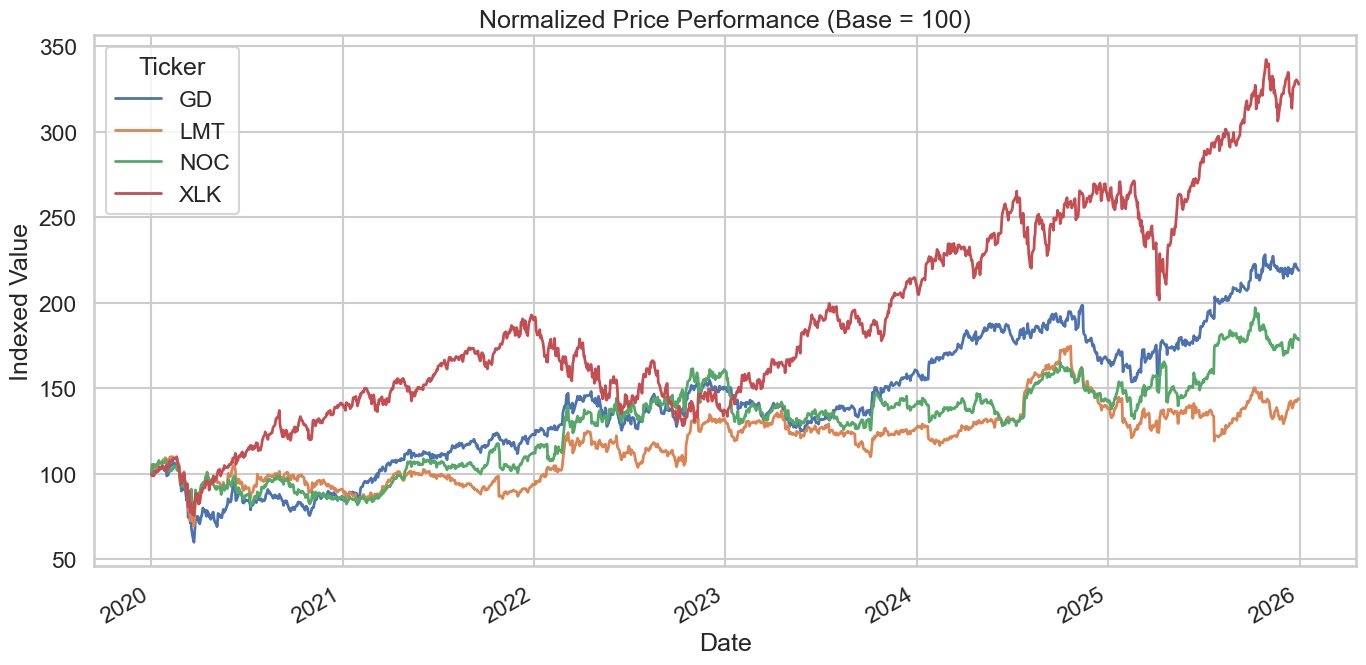

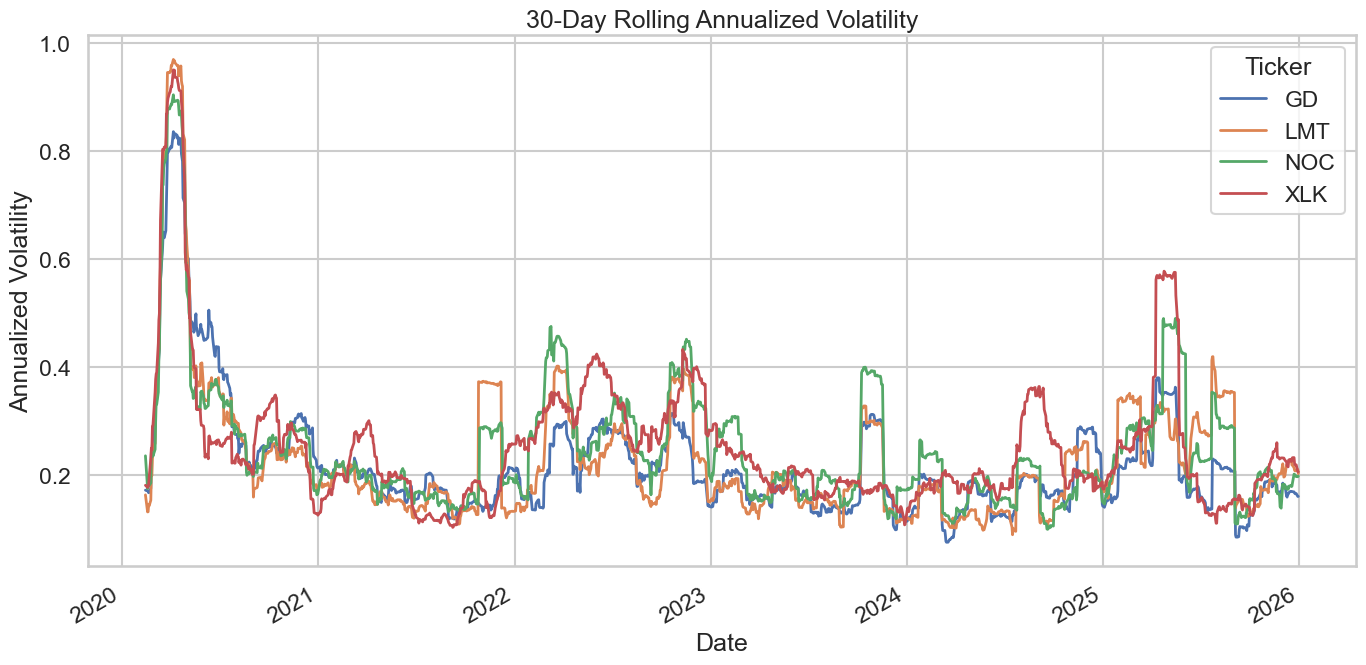

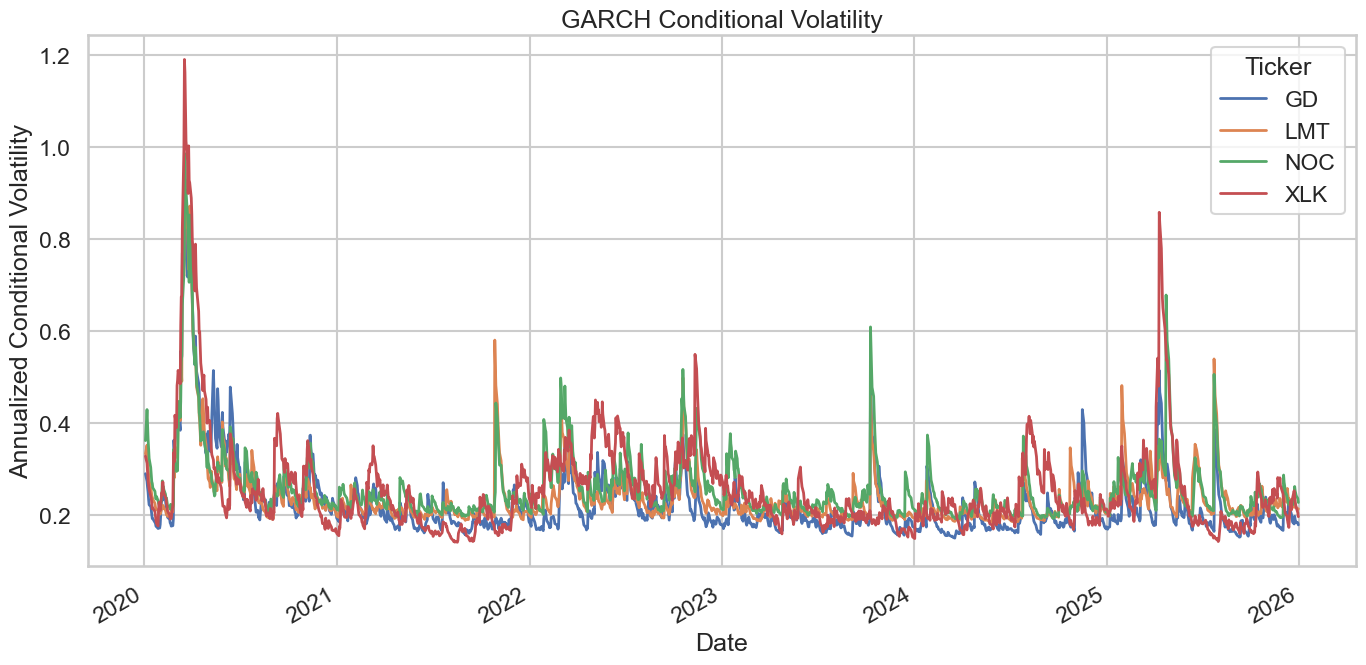

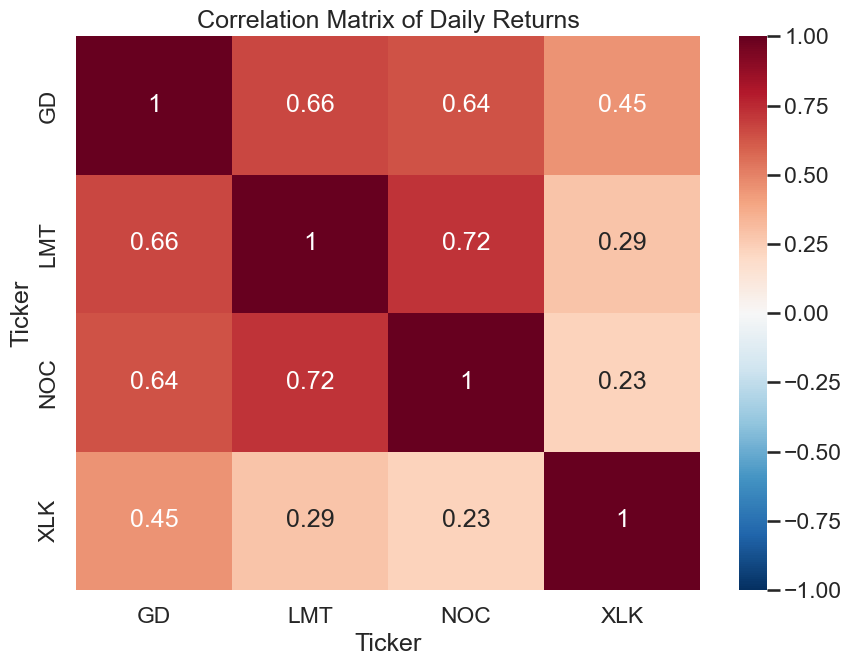

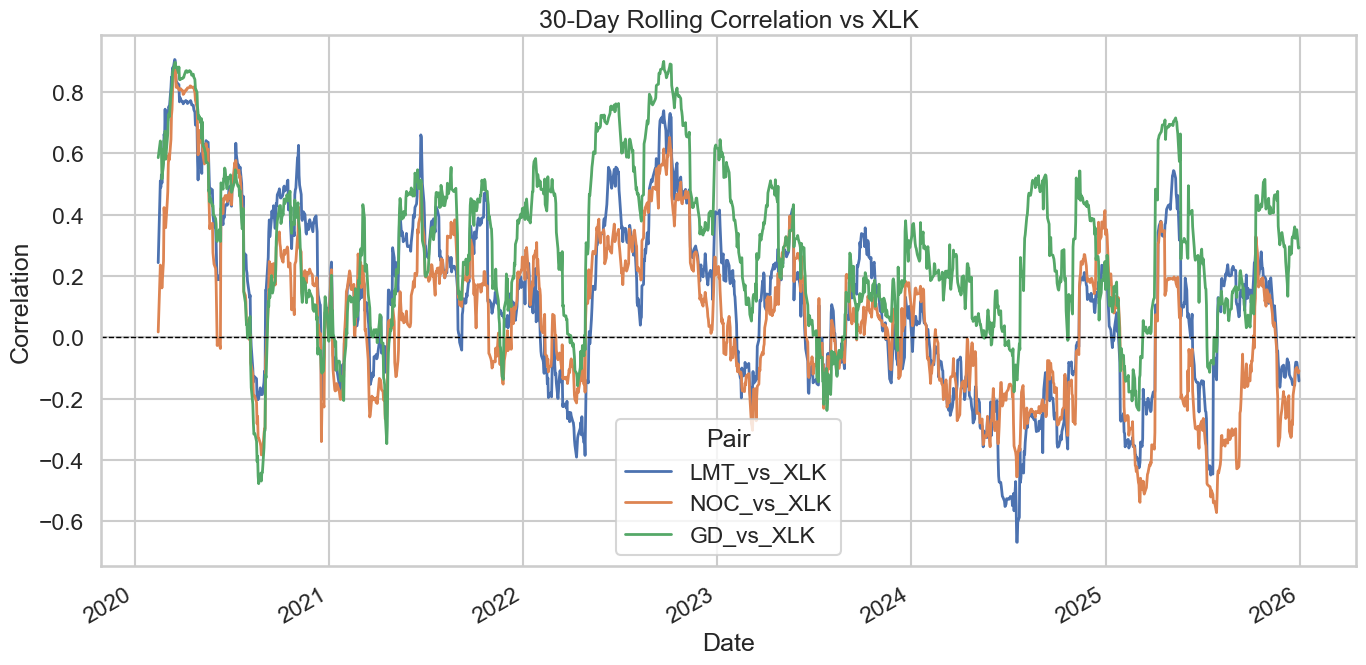

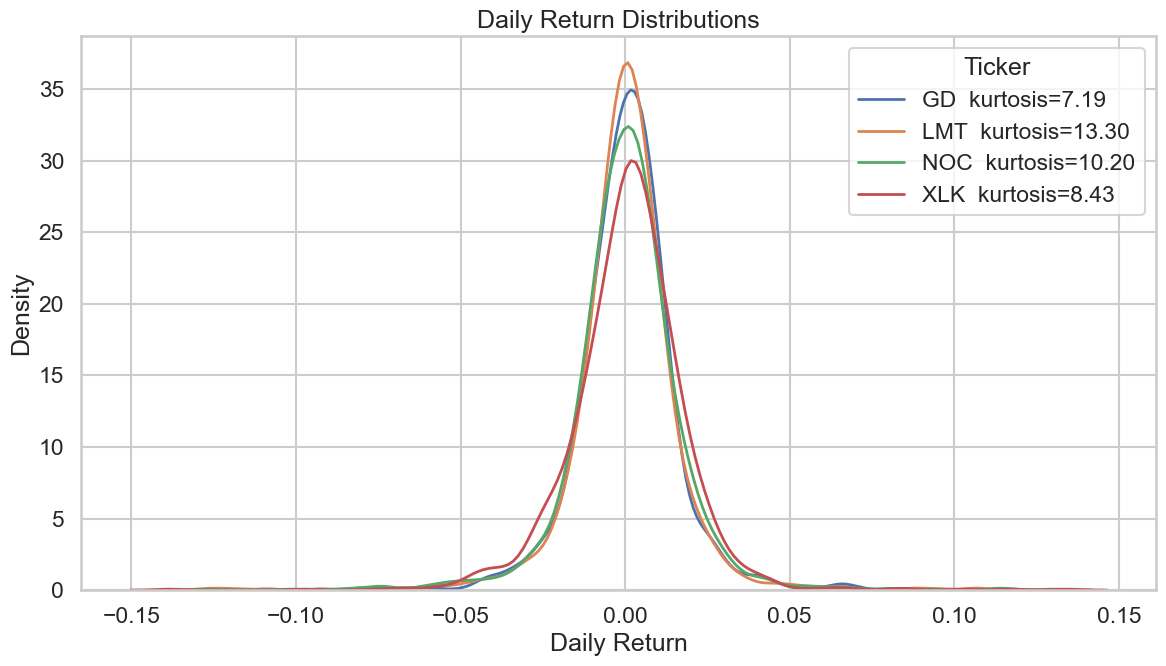

In [97]:
# core charts
plot_price_evolution(adj_close)
plt.show()

plot_rolling_volatility(rolling_vol, ROLLING_WINDOW)
plt.show()

plot_garch_volatility(garch_vol)
plt.show()

plot_correlation_matrix(correlation_matrix)
plt.show()

plot_rolling_correlation(rolling_corr_vs_xlk, ROLLING_WINDOW)
plt.show()

plot_returns_distribution(returns)
plt.show()

### Chart Notes

- **Normalized price performance:** compares cumulative performance from a common starting value.
- **Rolling volatility:** shows how risk changed over time rather than treating volatility as fixed.
- **GARCH volatility:** estimates conditional volatility, meaning the model's current reading of how unstable each series is given recent market shocks.
- **Correlation matrix:** shows how closely defense names moved with one another and with `XLK`.
- **Rolling correlation vs XLK:** shows whether diversification benefits were stable or regime-dependent.
- **Return distributions:** show dispersion and tail behavior beyond average returns. Higher kurtosis means fatter tails and more extreme moves.

## Strategy Section 1: Regime Strategy

This section keeps both versions of the regime strategy:

- the original biased version, which uses same-day information and therefore overstates performance
- the corrected lagged version, which waits one trading day before acting on the signal

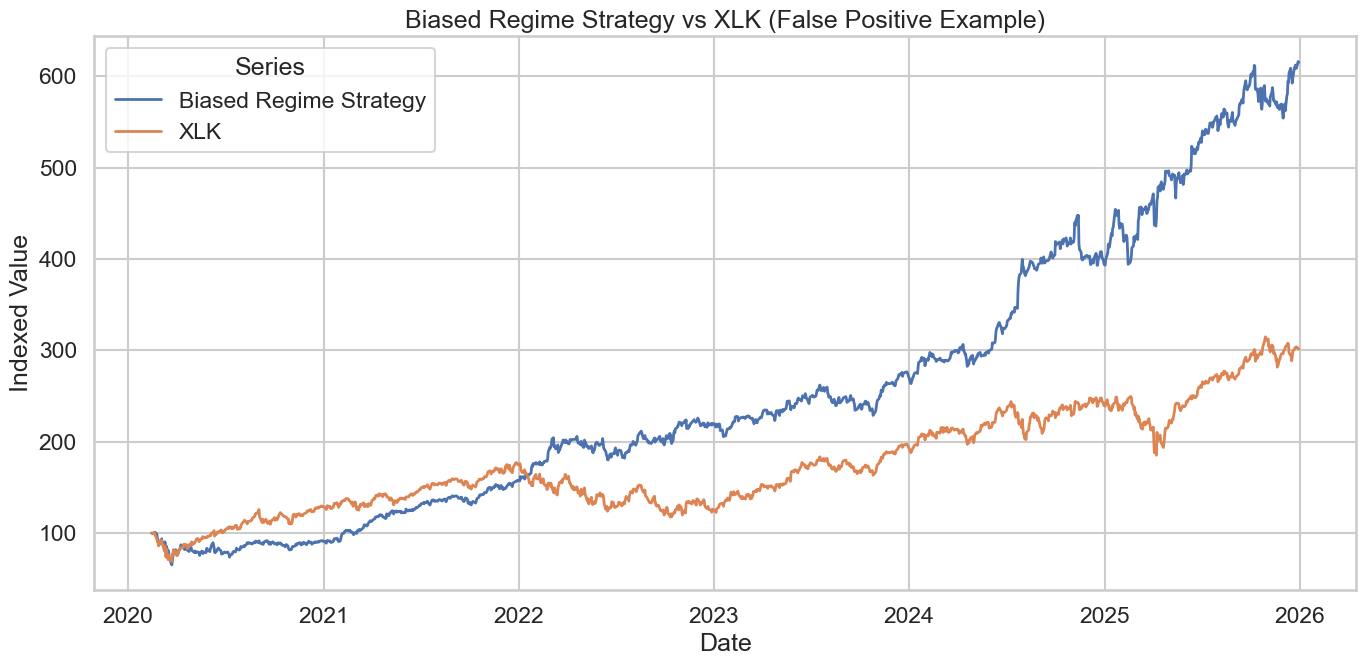

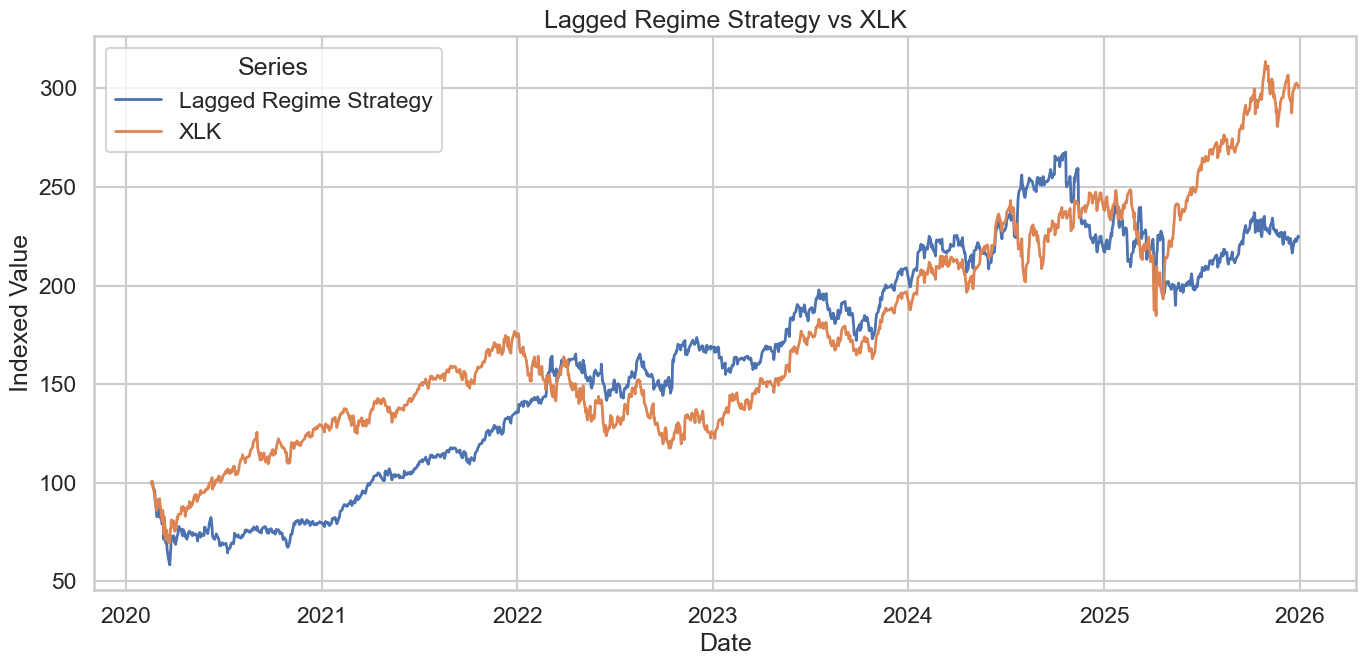

,annual_return,annual_volatility,max_drawdown
Strategy,0.1482,0.2571,-0.4213
XLK,0.2065,0.2806,-0.3356


,signal_date,trade_date,chosen_asset,signal_state,strategy_return,benchmark_return
0,2020-02-14,2020-02-18,XLK,Low Vol -> Hold XLK,-0.0037,-0.0037
1,2020-02-18,2020-02-19,XLK,Low Vol -> Hold XLK,0.0119,0.0119
2,2020-02-19,2020-02-20,XLK,Low Vol -> Hold XLK,-0.0104,-0.0104
3,2020-02-20,2020-02-21,XLK,Low Vol -> Hold XLK,-0.0224,-0.0224
4,2020-02-21,2020-02-24,GD,Medium Vol -> Momentum GD,-0.0159,-0.0413
5,2020-02-24,2020-02-25,GD,Medium Vol -> Momentum GD,-0.0579,-0.0320
6,2020-02-25,2020-02-26,GD,Medium Vol -> Momentum GD,-0.0136,0.0046
7,2020-02-26,2020-02-27,LMT,Medium Vol -> Momentum LMT,-0.0407,-0.0539
8,2020-02-27,2020-02-28,LMT,High Vol -> Low-Vol LMT,-0.0323,0.0076
9,2020-02-28,2020-03-02,NOC,High Vol -> Low-Vol NOC,0.0217,0.0578


In [98]:
# regime strategy charts
plot_strategy_curve(
    biased_regime_curve,
    xlk_curve_for_biased,
    "Biased Regime Strategy vs XLK (False Positive Example)",
    "Biased Regime Strategy",
)
plt.show()

plot_strategy_curve(
    regime_curve,
    xlk_curve_for_regime,
    "Lagged Regime Strategy vs XLK",
    "Lagged Regime Strategy",
)
plt.show()

display(regime_strategy_summary)
display(regime_log.head(10))

## Strategy Section 2: Momentum With Defense Filter

Rule summary:

- stay in `XLK` by default
- only rotate when `XLK` 30-day momentum is negative
- require a defense stock to have positive 30-day momentum and lower rolling volatility than `XLK`
- if multiple names qualify, choose the strongest-momentum defense stock

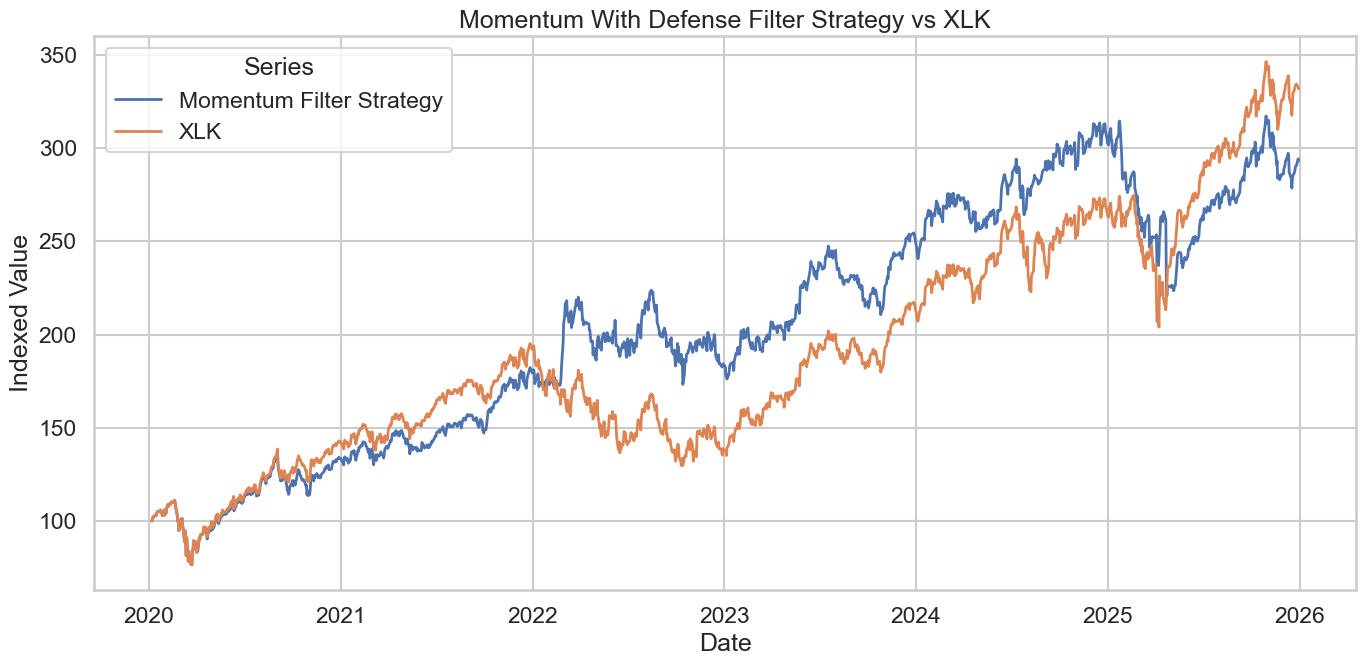

,annual_return,annual_volatility,max_drawdown
Strategy,0.1974,0.2625,-0.3115
XLK,0.2223,0.2790,-0.3356


,signal_date,trade_date,chosen_asset,signal_state,strategy_return,benchmark_return,xlk_30d_momentum
0,2020-01-03,2020-01-06,XLK,Hold XLK,0.0024,0.0024,NaN
1,2020-01-06,2020-01-07,XLK,Hold XLK,-0.0004,-0.0004,NaN
2,2020-01-07,2020-01-08,XLK,Hold XLK,0.0107,0.0107,NaN
3,2020-01-08,2020-01-09,XLK,Hold XLK,0.0113,0.0113,NaN
4,2020-01-09,2020-01-10,XLK,Hold XLK,-0.0023,-0.0023,NaN
5,2020-01-10,2020-01-13,XLK,Hold XLK,0.0125,0.0125,NaN
6,2020-01-13,2020-01-14,XLK,Hold XLK,-0.0047,-0.0047,NaN
7,2020-01-14,2020-01-15,XLK,Hold XLK,0.0012,0.0012,NaN
8,2020-01-15,2020-01-16,XLK,Hold XLK,0.0134,0.0134,NaN
9,2020-01-16,2020-01-17,XLK,Hold XLK,0.0067,0.0067,NaN


In [99]:
# momentum filter chart
plot_strategy_curve(
    momentum_curve,
    xlk_curve_for_momentum,
    "Momentum With Defense Filter Strategy vs XLK",
    "Momentum Filter Strategy",
)
plt.show()

display(momentum_strategy_summary)
display(momentum_log.head(10))

In [100]:
# insight generation
best_return = summary_stats["annual_return"].idxmax()
lowest_vol = summary_stats["annual_volatility"].idxmin()
weakest_corr = correlation_matrix.loc[DEFENSE_TICKERS, TECH_TICKER].idxmin()
strongest_fit = pair_regression_table["r_squared"].idxmax()
most_tail_risk = summary_stats.loc[DEFENSE_TICKERS + [TECH_TICKER], "kurtosis"].idxmax()

print("Key takeaways:")
print(f"1. {best_return} had the highest annualized return over the full sample.")
print(f"2. {lowest_vol} had the lowest annualized volatility over the sample.")
print(f"3. {weakest_corr} had the weakest full-period return correlation to {TECH_TICKER}, making it the best candidate for conditional diversification.")
print(f"4. {strongest_fit} had the strongest regression fit versus {TECH_TICKER}, meaning it moved most like tech among the defense names.")
print(f"5. {most_tail_risk} showed the highest kurtosis, meaning it had the fattest return tails and the greatest tendency toward outsized moves.")
print("6. The strategy tests are useful mainly as diagnostics: they show how easy it is to overstate signal quality and how difficult it was to beat a strong XLK trend with simple defense overlays.")

Key takeaways:
1. XLK had the highest annualized return over the full sample.
2. GD had the lowest annualized volatility over the sample.
3. NOC had the weakest full-period return correlation to XLK, making it the best candidate for conditional diversification.
4. GD had the strongest regression fit versus XLK, meaning it moved most like tech among the defense names.
5. LMT showed the highest kurtosis, meaning it had the fattest return tails and the greatest tendency toward outsized moves.
6. The strategy tests are useful mainly as diagnostics: they show how easy it is to overstate signal quality and how difficult it was to beat a strong XLK trend with simple defense overlays.


## Final Reflection Prompts

1. Which defense stock looked most independent from `XLK` over time?
2. Did lower correlation also coincide with lower volatility or better drawdown behavior?
3. Which defense stock behaved most like a tech-sensitive equity rather than a defensive diversifier?
4. Did the regularized models materially outperform plain OLS on the next-day prediction task, or was predictive signal weak?
5. Why did the biased regime strategy look much stronger than the corrected lagged version?
6. What did the GARCH chart add beyond the simple rolling volatility chart?